In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt

2026-05-24 18:26:15.118678: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True)

In [7]:
import os
print(os.getcwd())

/Users/m.mi/Desktop/anaconda_projects/Final3/Fashion_project


In [13]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import os
import shutil

# Read CSV file
df = pd.read_csv('styles.csv', on_bad_lines='skip')

# Selected classes for project
selected_classes = ['Dresses', 'Caps', 'Shoes', 'Bags']

# Create train folders
for category in selected_classes:
    os.makedirs(f'dataset/train/{category}', exist_ok=True)

# Source image folder
image_folder = 'dataset/images'

# Copy images into class folders
count = 0

for index, row in df.iterrows():

    try:
        image_id = str(row['id']) + '.jpg'
        category = row['articleType']

        if category in selected_classes:

            source = os.path.join(image_folder, image_id)
            destination = os.path.join(
                'dataset/train',
                category,
                image_id
            )

            # Copy image
            if os.path.exists(source):
                shutil.copy(source, destination)
                count += 1

    except:
        pass

print("Images copied:", count)

Images copied: 747


In [23]:
print(os.listdir('dataset/train'))

['Caps', 'Dresses', 'Bags', 'Shoes']


In [22]:
for category in selected_classes:
    path = f'dataset/train/{category}'
    print(category, len(os.listdir(path)))

Dresses 464
Caps 283
Shoes 0
Bags 0


In [21]:
train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 599 images belonging to 4 classes.


In [26]:
val_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 148 images belonging to 4 classes.


In [27]:
print(train_data.class_indices)

{'Bags': 0, 'Caps': 1, 'Dresses': 2, 'Shoes': 3}


In [28]:
model = Sequential()

# First CNN Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Second CNN Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third CNN Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convert to 1D
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Prevent Overfitting
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

In [29]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

In [31]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


2026-05-24 18:45:03.017728: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


19/19 [==============================] - ETA: 0s - loss: 0.5039 - accuracy: 0.7846

2026-05-24 18:45:09.089327: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


19/19 [==============================] - 7s 309ms/step - loss: 0.5039 - accuracy: 0.7846 - val_loss: 0.3138 - val_accuracy: 0.8514
Epoch 2/10
19/19 [==============================] - 6s 304ms/step - loss: 0.1374 - accuracy: 0.9599 - val_loss: 0.3025 - val_accuracy: 0.8581
Epoch 3/10
19/19 [==============================] - 6s 298ms/step - loss: 0.1383 - accuracy: 0.9566 - val_loss: 0.2532 - val_accuracy: 0.9122
Epoch 4/10
19/19 [==============================] - 5s 284ms/step - loss: 0.0895 - accuracy: 0.9699 - val_loss: 0.2133 - val_accuracy: 0.9122
Epoch 5/10
19/19 [==============================] - 5s 279ms/step - loss: 0.1194 - accuracy: 0.9633 - val_loss: 0.2594 - val_accuracy: 0.8851
Epoch 6/10
19/19 [==============================] - 6s 287ms/step - loss: 0.0877 - accuracy: 0.9683 - val_loss: 0.4880 - val_accuracy: 0.8581
Epoch 7/10
19/19 [==============================] - 6s 292ms/step - loss: 0.1219 - accuracy: 0.9633 - val_loss: 0.3553 - val_accuracy: 0.7905
Epoch 8/10
19/19 

In [32]:
model.save("model.h5")

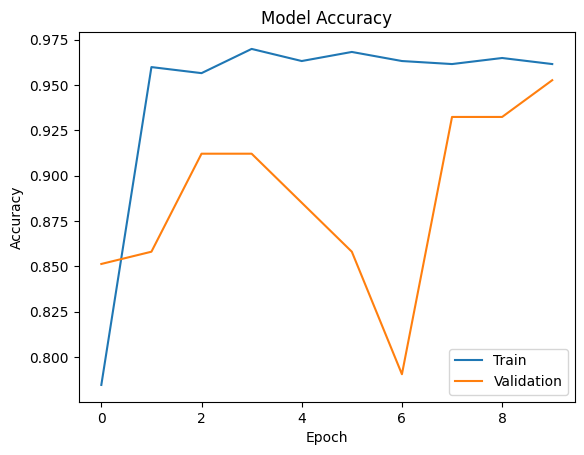

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

In [34]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [55]:
img = image.load_img('test.jpg',
                     target_size=(128,128))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

1/1 [==============================] - 0s 32ms/step
[[3.1015853e-04 4.8293162e-02 9.5118326e-01 2.1342473e-04]]


In [56]:
class_names = ['Bags', 'Caps', 'Dresses', 'Shoes']

predicted_class = class_names[np.argmax(prediction)]

print("Prediction:", predicted_class)

Prediction: Dresses
